In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

from dermaml import data


In [3]:
IMAGE_DIR = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/images_sample/'
TMP_PATH = '0a7e51d5-c15f-4633-8191-f7252a3c33ae.jpeg'

filenames, images = data.read_local(IMAGE_DIR, )
test_im = cv.cvtColor(images[0], cv.COLOR_BGR2RGB)

100%|██████████| 11/11 [00:00<00:00, 18.73it/s]


In [4]:
test_im[0, 0]

array([ 75, 166, 105], dtype=uint8)

In [5]:
def get_RGBA(im, x, y):
    '''
    `im` is an RGB image
    '''
    rgba_im = cv.cvtColor(im, cv.COLOR_RGB2RGBA)
    R, G, B, A = rgba_im[x, y]
    return R, G, B, A

def get_HSV(im, x, y):
    '''
    `im` is an RGB image
    '''
    hsv_im = cv.cvtColor(im.astype('float32'), cv.COLOR_RGB2HSV)
    H, S, V = hsv_im[x, y]
    return H, S, V

def get_YCbCr(im, x, y):
    R, G, B, _ = get_RGBA(im, x, y)
    Y = (0.299*R) + (0.287*G) + (0.11*B)
    Cb = B - Y
    Cr = R - Y
    return Y, Cb, Cr

def skin_condition_1(H, S, R, G, B, A):
    if (
        (0 <= H) 
        and (H <= 50.0)
        and (0.23 <= S) 
        and (S <= 0.68)
        and (95 < R)
        and (40 < G)
        and (20 < B)
        and (R > G)
        and (R > B)
        and (15 < A)
        and (15 < np.abs(R - G))
        ):
        return True
    else:
        return False
    
def skin_condition_2(Y, Cb, Cr, R, G, B, A):
    if (
        (95 < R)
        and (40 < G)
        and (20 < B)
        and (R > G)
        and (R > B)
        and (15 < A)
        and (15 < np.abs(R - G))
        and (135 < Cr)
        and (85 < Cb)
        and (80 < Y)
        and (Cr <= (1.5862*Cb)+20)
        and (Cr>=(0.3448*Cb)+76.2069)
        and (Cr >= (-4.5652*Cb)+234.5652)
        and (Cr <= (-1.15*Cb)+301.75) 
        and (Cr <= (-2.2857*Cb)+432.85)
        ):
        return True
    else:
        return False

def is_skin(im, x, y):
    '''
    `im` is an RGB image
    function determines whether a pixel in an image is skin or not skin
    '''
    R, G, B, A = get_RGBA(im, x, y)
    H, S, V = get_HSV(im, x, y)
    Y, Cb, Cr = get_YCbCr(im, x, y)

    if (skin_condition_1(H, S, R, G, B, A)):
        return True
    if (skin_condition_2(Y, Cb, Cr, R, G, B, A)):
        return True
    return False


False
(4032, 3024, 3)


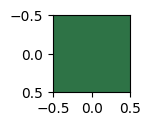

In [5]:
x, y = 2010, 2010 
skin = is_skin(test_im, x, y)
print(skin)
print(test_im.shape)

plt.figure(figsize=(1,1))
plt.imshow(test_im[x:x+1, y:y+1])
plt.show()

Results for is_skin conditions are not similar to accuracy reported in paper.  
Many of the images with wrinkled background and cold lighting or (cold lighting + blue green veins) are not captured. Condition 2 is not functional, with condition 1 marking most items as true. Several clauses in condition 2 are not functional. The most hand is captured when commenting out the lines with double pound sign. However, this also captures background noise which needs to be eliminated. I think there needs to be another OR clause in condition 2, though I cannot think clearly enough to find it. 

In [226]:
def is_skin_vectorized(image):
    '''
    Vectorized operation to determine whether each pixel in the image is skin or not skin
    Modified from 2017 Kolkur et al. 
    Accuracy reported in paper is not reproducible. See Figure 6.
    '''
    im = cv.GaussianBlur(image, (15, 15), 0)
    # Extract RGBA values
    rgba_im = cv.cvtColor(im, cv.COLOR_RGB2RGBA)
    R, G, B, A = rgba_im[:,:,0], rgba_im[:,:,1], rgba_im[:,:,2], rgba_im[:,:,3]
    
    # Extract HSV values
    hsv_im = cv.cvtColor(im.astype('float32'), cv.COLOR_RGB2HSV)
    H, S, V = hsv_im[:,:,0], hsv_im[:,:,1], hsv_im[:,:,2]
    
    # Extract YCbCr values
    Y = (0.299*R) + (0.287*G) + (0.11*B)
    Cb = B - Y
    Cr = R - Y

    skin_cond_1 =   (  ## carrying condition
        (95 < R) & (40 < G) & (20 < B) & (15 < A)
        & (R > G) & (R > B) 
        & (15 < np.abs(R - G))
        & (0 <= H) & (H <= 50.0)
        & (0.23 <= S) & (S <= 0.68)
        )
    
    diff = 15
    skin_cond_2 = ( 
        (95 < R) 
        & (40 < G)
        & (20 < B) 
        & (15 < A) 
        & (R > G) 
        & (R > B) 

        # & (diff < np.abs(R - G)) # polarizing
        # & (135 < Cr) & (85 < Cb) & (80 < Y) # BAD.
        
        # below section cannot work together in ANDs
        & (
            (Cr <= (1.5862*Cb) +20) # and?
            | (Cr>= (0.3448*Cb)+76.2069) # POLARIZING
            | (Cr >= (-4.5652*Cb)+234.5652) # okay
        )

        & (Cr <= (-1.15*Cb)+301.75) 
        & (Cr <= (-2.2857*Cb)+432.85)
        )
    
    skin_cond_3 = (
        (R < 230) 
        & (G < 230)
        & (B < 230) 
    )
        
    
    # Combine the conditions
    skin_mask = (skin_cond_1 | skin_cond_2) & skin_cond_3
    return skin_mask


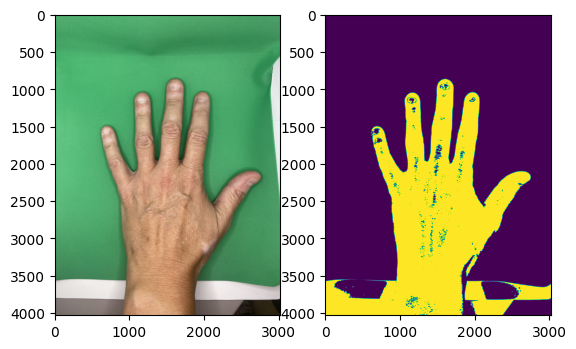

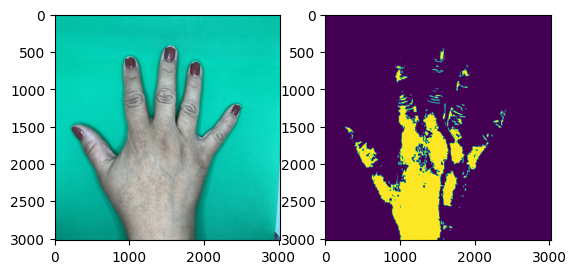

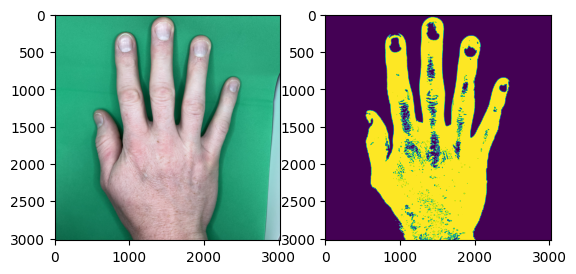

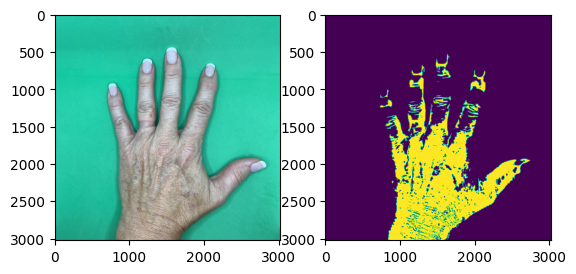

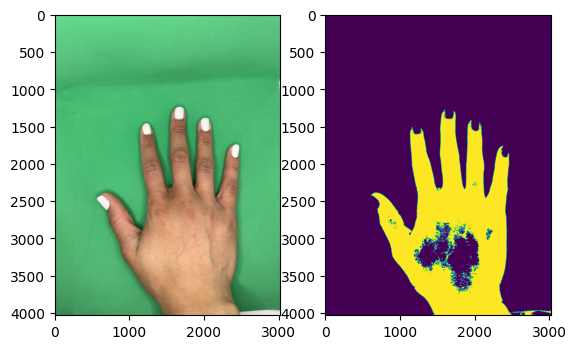

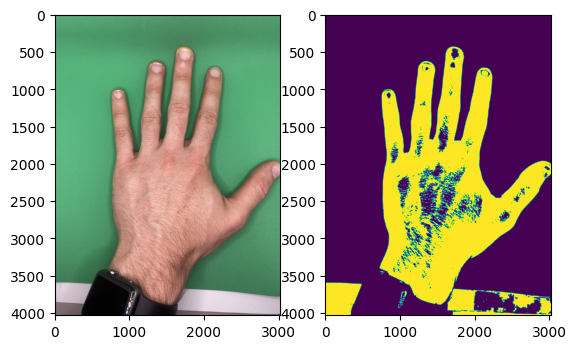

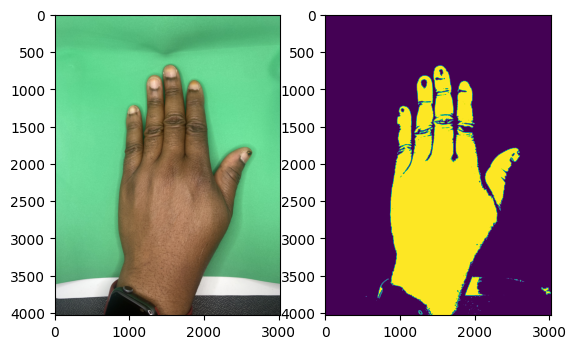

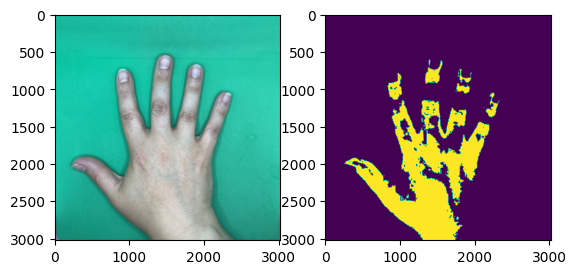

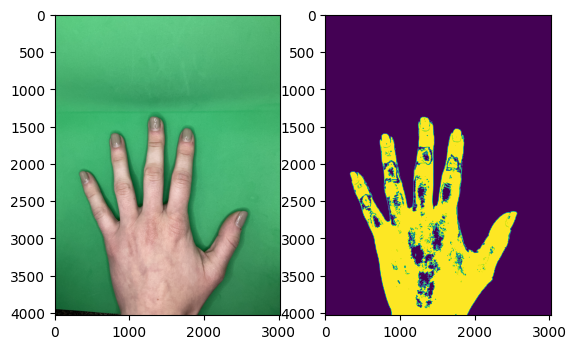

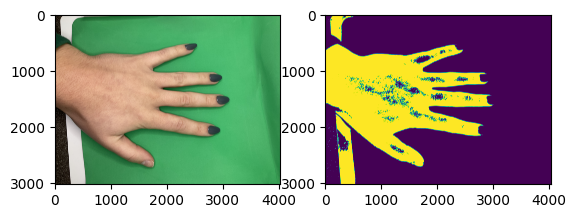

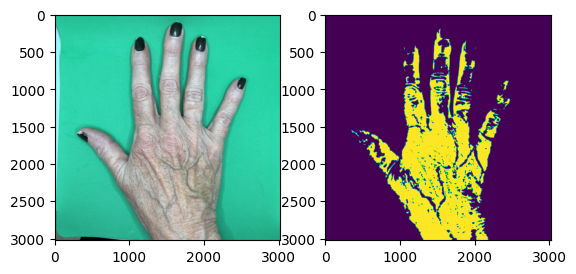

In [227]:
masks = []
for i in images:
    im = cv.cvtColor(i, cv.COLOR_BGR2RGB)
    mask = is_skin_vectorized(im)

    fig, ax = plt.subplots(ncols=2, nrows=1)
    ax[0].imshow(im)
    ax[1].imshow(mask)
    plt.show()

In [6]:
import pandas as pd

def report_colors_dict(image):
    # -- APPLY GAUSSIAN BLUR
    im = cv.GaussianBlur(image, (15, 15), 0)

    # -- GET RGB VALUES
    rgba_im = cv.cvtColor(im, cv.COLOR_RGB2RGBA)
    R, G, B, A = rgba_im[:,:,0], rgba_im[:,:,1], rgba_im[:,:,2], rgba_im[:,:,3]
    R, G, B, A = R.flatten(), G.flatten(), B.flatten(), A.flatten(),

    # --- GET HSV VALUES
    hsv_im = cv.cvtColor(im.astype('float32'), cv.COLOR_RGB2HSV)
    H, S, V = hsv_im[:,:,0], hsv_im[:,:,1], hsv_im[:,:,2]
    H, S, V = H.flatten(), S.flatten(), V.flatten(),

    # --- GET YCbCr VALUES
    Y = (0.299*R) + (0.287*G) + (0.11*B)
    Cb = B - Y
    Cr = R - Y

    # -- SKIN CONDITION 1
    skin_cond_1 =   (  ## carrying condition
        (95 < R) & (40 < G) & (20 < B) & (15 < A)
        & (R > G) & (R > B) 
        & (15 < np.abs(R - G))
        & (0 <= H) & (H <= 50.0)
        & (0.23 <= S) & (S <= 0.68)
        )
    
    # -- SKIN CONDITION 2
    skin_cond_2 = ( 
        (95 < R) & (40 < G) & (20 < B)  & (15 < A) 
        & (R > G) & (R > B) 
        # below section cannot work together in ANDs
        & (
            (Cr <= (1.5862*Cb) +20) # and?
            | (Cr>= (0.3448*Cb)+76.2069) # POLARIZING
            | (Cr >= (-4.5652*Cb)+234.5652) # okay
        )
        & (Cr <= (-1.15*Cb)+301.75) 
        & (Cr <= (-2.2857*Cb)+432.85)
        )
    
    # -- CREATE DICT
    colorbook = {
        "R":R,"G":G,"B":B,"A":A,
        "H":H,"S":S,"V":V,
        "Y":Y,"Cb":Cb,"Cr":Cr,
        "Cond_1":skin_cond_1,
        "Cond_2":skin_cond_2,
        "Skin?":skin_cond_1|skin_cond_2
    }

    # CREATE DFs
    report = pd.DataFrame(colorbook)

    # report base condition
    colorbook_base_cond = report.copy()
    colorbook_base_cond.loc[:, 'R'] = 95 - R
    colorbook_base_cond.loc[:, 'G'] = 40 - G
    colorbook_base_cond.loc[:, 'B'] = 20 - B
    colorbook_base_cond.loc[:, 'A'] = 15 - A
    colorbook_base_cond.loc[:, 'R-G'] = np.abs(R - G)
    colorbook_base_cond = colorbook_base_cond[['R', 'G', 'B', 'A', 'R-G', 'Cond_1', 'Cond_2','Skin?',]]

    # report HSV conditions
    colorbook_cond1 = report.copy()
    colorbook_cond1.loc[:, 'H'] = 50 - H
    colorbook_cond1.loc[:, 'S_upper'] = 0.68 - S
    colorbook_cond1.loc[:, 'S_lower'] = S - 0.23
    colorbook_cond1 = colorbook_cond1[['H', 'S_upper', 'S_lower', 'Cond_1', 'Cond_2','Skin?',]]

    # report YCbCr conditions
    colorbook_cond2 = report.copy()
    # colorbook_cond2.loc[:, 'Cr_lower'] = Cr - 135
    # colorbook_cond2.loc[:, 'Cb_lower'] = Cr - 85
    # colorbook_cond2.loc[:, 'Y'] = Y - 80
    colorbook_cond2.loc[:, 'Cr_1_OR'] = ((1.5862*Cb) +20 ) - Cr
    colorbook_cond2.loc[:, 'Cr_2_OR'] = Cr - ((0.3448*Cb)+76.2069)
    colorbook_cond2.loc[:, 'Cr_3_OR'] = Cr - ((-4.5652*Cb)+234.5652)
    colorbook_cond2.loc[:, 'Cr_4'] = ((-1.15*Cb)+301.75) - Cr 
    colorbook_cond2.loc[:, 'Cr_5'] = ((-2.2857*Cb)+432.85) - Cr
    colorbook_cond2 = colorbook_cond2[[
        # 'Cr_lower', 'Cb_lower', 'Y', 
                                    'Cr_1_OR', 'Cr_2_OR', 'Cr_3_OR', 'Cr_4', 'Cr_5',
                                    'Cond_1', 'Cond_2','Skin?',]]
    
    return report, colorbook_base_cond, colorbook_cond1, colorbook_cond2

In [7]:
colorbook, colorbook_base_cond, colorbook_cond1, colorbook_cond2 = report_colors_dict(test_im)

In [11]:
colorbook_cond2

,Cr_1_OR,Cr_2_OR,Cr_3_OR,Cr_4,Cr_5,Cond_1,Cond_2,Skin?
0,65.489163,-88.894550,-117.515920,274.94055,376.031949,False,False,False
1,65.489163,-88.894550,-117.515920,274.94055,376.031949,False,False,False
2,65.489163,-88.894550,-117.515920,274.94055,376.031949,False,False,False
3,65.489163,-88.894550,-117.515920,274.94055,376.031949,False,False,False
4,65.489163,-88.894550,-117.515920,274.94055,376.031949,False,False,False
...,...,...,...,...,...,...,...,...
12192763,4.781233,-65.686832,-242.629482,296.88775,432.286375,False,False,False
12192764,7.300020,-67.106980,-239.704280,296.98500,431.378530,False,False,False
12192765,8.475294,-67.911075,-239.040285,297.34215,431.396106,False,False,False
12192766,8.297089,-68.110256,-240.732106,297.99575,432.394958,False,False,False


In [30]:
n_picks = 10
case = colorbook_cond2[~(colorbook_cond2['Cond_2']) & (colorbook_cond2['Cond_1'])].sample(10)
case

,Cr_1_OR,Cr_2_OR,Cr_3_OR,Cr_4,Cr_5,Cond_1,Cond_2,Skin?
6410560,-18.492236,-32.403954,-169.757274,251.55230,377.793775,True,False,True
5831903,-62.736439,-1.383145,-191.037785,236.45410,374.793052,True,False,True
10238075,-69.560450,-11.128099,-266.316509,266.15015,419.647290,True,False,True
4625536,-38.615810,-8.306659,-129.943069,222.67015,345.276250,True,False,True
4105035,-26.829187,-20.545152,-143.968802,235.45275,358.472244,True,False,True
8316947,-36.966529,-17.051782,-166.753752,239.95955,369.057311,True,False,True
8681096,-52.140631,-2.246377,-153.406617,225.59810,355.033164,True,False,True
8823171,-56.181136,-0.409357,-160.284847,226.41435,357.865281,True,False,True
10086085,-55.943139,-0.143346,-158.025376,225.54145,356.531287,True,False,True
3788068,-34.156701,-7.558095,-108.597055,215.65090,333.492738,True,False,True


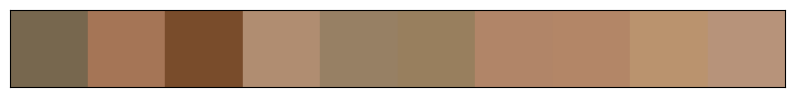

In [31]:
# get color of sampled cases.
pixel_instances = colorbook.loc[case.index]
rgb_values = pixel_instances[['R', 'G', 'B', 'A']].to_numpy()

fig, ax = plt.subplots(figsize=(n_picks,1))

# Create a grid of patches
for i, color in enumerate(rgb_values):
    patch = plt.Rectangle((i % n_picks, i // n_picks), 1, 1, color=color/255)
    ax.add_patch(patch)

ax.set_xlim(0, n_picks)
ax.set_xticks([])
ax.set_yticks([])
plt.show()